# Spectral Dimension Extraction for SM8 Cage Graph  
This notebook loads the GPU‑generated return‑probability CSV and fits  
\[
P(t) \sim t^{-d_s/2}
\]  
to extract the spectral dimension \( d_s \).



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("nb02_SM8_return_prob_data_current_graph.csv")

t_vals = df["t"].values
P_t = df["P(t)"].values

print("Loaded", len(t_vals), "time steps")

Loaded 2001 time steps


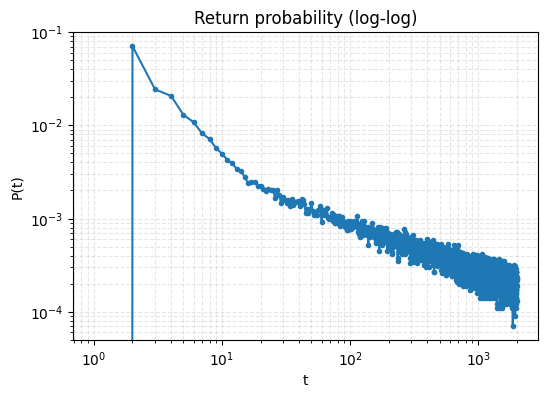

In [18]:
plt.figure(figsize=(6,4))
plt.loglog(t_vals[1:], P_t[1:], 'o-', markersize=3)
plt.xlabel("t")
plt.ylabel("P(t)")
plt.title("Return probability (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

In [19]:
t_min, t_max = 20, 200
print("Scaling window:", t_min, "to", t_max)

Scaling window: 20 to 200


In [20]:
mask = (t_vals >= t_min) & (t_vals <= t_max)

log_t = np.log(t_vals[mask])
log_P = np.log(P_t[mask])

print("Points in window:", len(log_t))

Points in window: 181


In [21]:
slope, intercept = np.polyfit(log_t, log_P, 1)
d_s = -2 * slope

print(f"Slope m = {slope:.6f}")
print(f"Spectral dimension d_s = {d_s:.6f}")

Slope m = -0.533577
Spectral dimension d_s = 1.067153


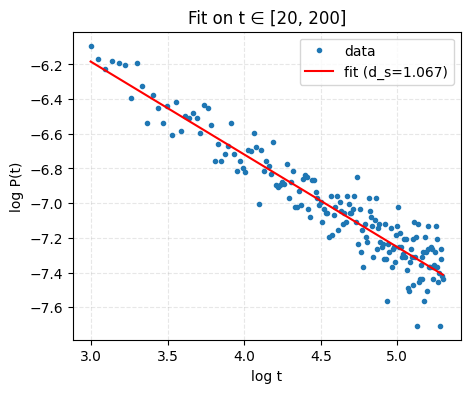

In [22]:
plt.figure(figsize=(5,4))
plt.plot(log_t, log_P, "o", markersize=3, label="data")
plt.plot(log_t, slope*log_t + intercept, "r-", label=f"fit (d_s={d_s:.3f})")
plt.xlabel("log t")
plt.ylabel("log P(t)")
plt.legend()
plt.title(f"Fit on t ∈ [{t_min}, {t_max}]")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

In [23]:
# Save a copy of the return-probability data into the project notebooks folder
output_path = "nb02_SM8_return_prob_data_current_graph_copy.csv"
df.to_csv(output_path, index=False)
print("Saved CSV to:", output_path)

Saved CSV to: nb02_SM8_return_prob_data_current_graph_copy.csv
